In [1]:
import pandas as pd
from flaml.default import XGBClassifier as ZeroShotXGBClassifier
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer
import numpy as np
import shap
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

shap.initjs()

# Set Arial as the font family
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12         # Optional: adjust font size
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12


def split_data(X, y, test_size, random=True):
    if random:
        return train_test_split(X, y, stratify=y, test_size=test_size)
    else:

        pos_idxs = []
        for idx, y_ in enumerate(list(y)):
            if y_ == 1:
                pos_idxs += [idx]

        n = int(len(pos_idxs)*(1-test_size))
        cut_idx = pos_idxs[n]
                
        # Test set: only rows with indices in `test_pos_indices`
        X_test = X.iloc[cut_idx:]
        y_test = y.iloc[cut_idx:]

        # Train set: all other rows
        X_train = X.iloc[:cut_idx]
        y_train = y.iloc[:cut_idx]
    
        return X_train, X_test, y_train, y_test


def get_shapleys(model, df):
    columns = list(df.columns)
    df = df[df[columns[0]].notnull()]
    y = df[columns[0]].tolist()
    x = np.array(df[columns[1:]])
    print("Imputing missing values...")
    imp = SimpleImputer(strategy="mean")
    x = imp.fit_transform(x)
    x = pd.DataFrame(x, columns=columns[1:])
    mdl = model()
    print("Fitting model...")
    mdl.fit(x, y)
    print("Explainer")
    explainer = shap.TreeExplainer(mdl)
    print("Calculating SHAP values...")
    shap_values = explainer(x)
    print("Done")
    return explainer, shap_values, x, columns[1:], y


dataset_names = ["ml_d1_predelivery", "ml_d2_earlydeath", "ml_d3_latedeath"]


shap_results = []
for dn in dataset_names:
    if "_d1_" in dn:
        model = XGBClassifier
    else:
        model = ZeroShotXGBClassifier
    print("Processing dataset {0}".format(dn))
    df = pd.read_csv("../data/processed/{0}.csv".format(dn))
    col = list(df.columns)[0]
    if "_d1_" in dn:
        col = df.columns[0]
        vals = []
        for v in df[col].tolist():
            v = str(v)
            if v == "nan":
                vals += [None]
            else:
                if v == "Miscarriage or Stillbirth":
                    vals += [1]
                else:
                    vals += [0]
        df[col] = vals
        df[col] = df[col].astype(float)
        df = df.rename(columns={col: "Death"})
    else:
        col = df.columns[0]
        vals = []
        for v in df[col].tolist():
            v = str(v)
            if v == "nan":
                vals += [None]
            else:
                if v == "Dead":
                    vals += [1]
                else:
                    vals += [0]
        df[col] = vals
        df[col] = df[col].astype(float)
        df = df.rename(columns={col: "Death"})
    if "Birthweight Measure" in df.columns:
        df = df.drop(columns=['Birthweight Measure'], errors="ignor")
    if "Type of Delivery Place" in df.columns:
        df = df.drop(columns=['Type of Delivery Place'], errors="ignore")
    bmi = np.array(df["Maternal Weight"].tolist()) / (np.array(df["Maternal Height"].tolist()) / 100) ** 2
    df["BMI"] = np.clip(bmi, 10, 50)
    df = df.drop(columns=['Maternal Weight', 'Maternal Height'], errors='ignore')
    school_levels = []
    for x in df["School Level"].tolist():
        x = str(x)
        if x == "nan":
            school_levels += [None]
        else:
            school_levels += [int(x[0]) - 1]
    df["School Level"] = school_levels
    df["School Level"] = df["School Level"].astype(float)
    if "Pre-term Delivery" in df.columns:
        preterm = []
        for x in df["Pre-term Delivery"].tolist():
            x = str(x)
            if x == "nan":
                preterm += [None]
            else:
                if x == "Preterm":
                    preterm += [1]
                else:
                    preterm += [0]
        df["Pre-term Delivery"] = preterm
        df["Pre-term Delivery"] = df["Pre-term Delivery"].astype(float)
    if "Mode of Delivery" in df.columns:
        cesarean = []
        for x in df["Mode of Delivery"].tolist():
            x = str(x)
            if x == "nan":
                cesarean += [None]
            else:
                if x == "Cesarean":
                    cesarean += [1]
                else:
                    cesarean += [0]
        df["Mode of Delivery Cesarea"] = cesarean
        df["Mode of Delivery Cesarea"] = df["Mode of Delivery Cesarea"].astype(float)
        df = df.drop(columns=['Mode of Delivery'], errors='ignore')
    if "Baby Sex" in df.columns:
        baby_sex_female = []
        for x in df["Baby Sex"].tolist():
            x = str(x)
            if x == "nan":
                baby_sex_female += [None]
            else:
                if x == "Female":
                    baby_sex_female += [1]
                else:
                    baby_sex_female += [0]
        df["Baby Sex Female"] = baby_sex_female
        df["Baby Sex Female"] = df["Baby Sex Female"].astype(float)
        df = df.drop(columns=["Baby Sex"], errors='ignore')
    if "Delivery Place" in df.columns:
        delivery_home = []
        for x in df["Delivery Place"].tolist():
            x = str(x)
            if x == "nan":
                delivery_home += [None]
            else:
                if x == "Home":
                    delivery_home += [1]
                elif x == "Other":
                    delivery_home += [1]
                else:
                    delivery_home += [0]
        df["Delivery Place Home"] = delivery_home
        df["Delivery Place Home"] = df["Delivery Place Home"].astype(float)
        df = df.drop(columns=["Delivery Place"], errors='ignore')
    explainer, shap_values, X, feature_names, y = get_shapleys(model, df)
    shap_results += [(explainer, shap_values, X, feature_names, y)]
    print("Dataset {0} processed".format(dn))
    

/Users/mduranfrigola/miniconda3/envs/coadd/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Processing dataset ml_d1_predelivery
Imputing missing values...
Fitting model...
Explainer
Calculating SHAP values...
Done
Dataset ml_d1_predelivery processed
Processing dataset ml_d2_earlydeath
Imputing missing values...
Fitting model...
Explainer
Calculating SHAP values...
Done
Dataset ml_d2_earlydeath processed
Processing dataset ml_d3_latedeath
Imputing missing values...
Fitting model...
Explainer
Calculating SHAP values...
Done
Dataset ml_d3_latedeath processed


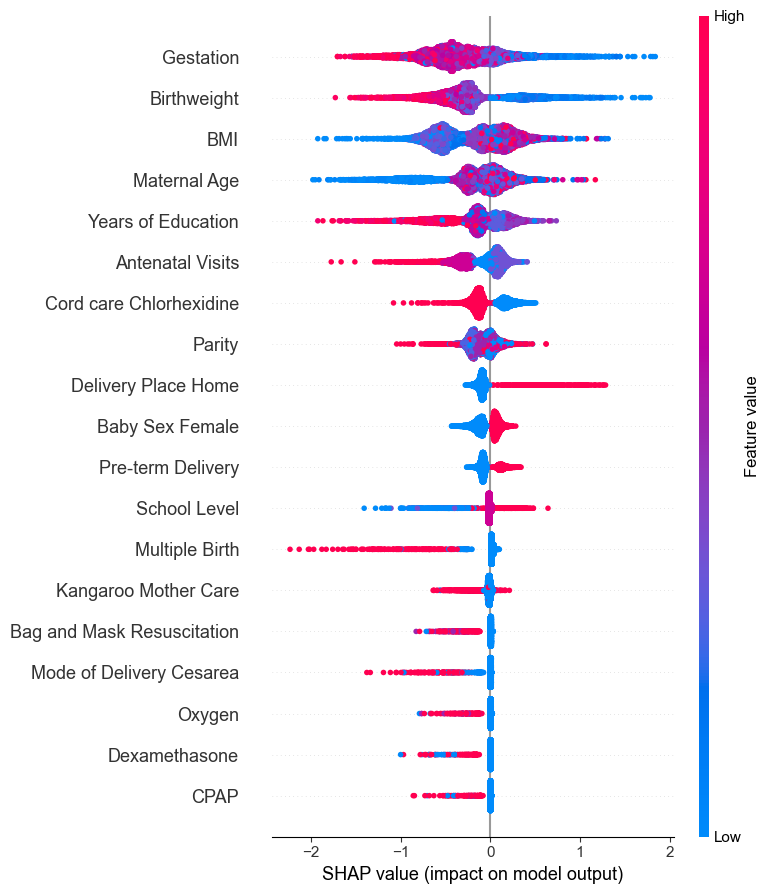

In [2]:
names = ["shapley_d1", "shapley_d2", "shapley_d3"]

shap_results = shap_results*3

fig, axs = plt.subplots(1, 3, figsize=(6, 5))

i = 0
for name, shap_result in zip(names, shap_results):
    ax = axs[i]
    explainer, shap_values, X, feature_names, y = shap_result
    shap.summary_plot(shap_values, X, feature_names=feature_names, show=False)
    plt.tight_layout()
    plt.savefig(f"../assets/{name}.png", bbox_inches='tight', dpi=300)
    i += 1



In [3]:
import shutil
import random
explainer, shap_values, X, feature_names, y = shap_results[1]

idxs = []
for idx in range(len(y)):
    if y[idx] == 1:
        idxs += [idx]

import os
dest_dir = "../assets/individual_shapley/"
if os.path.exists(dest_dir):
    shutil.rmtree(dest_dir)
os.mkdir(dest_dir)
for idx in idxs[:100]:
    shap.plots.waterfall(shap_values[idx], show=False)
    plt.savefig(f"{dest_dir}/pos_shapley_{idx}.png", bbox_inches='tight', dpi=300)
    plt.close()

idxs = [i for i in range(len(y)) if i not in idxs]
random.shuffle(idxs)
for idx in idxs[:100]:
    shap.plots.waterfall(shap_values[idx], show=False)
    plt.savefig(f"{dest_dir}/neg_shapley_{idx}.png", bbox_inches='tight', dpi=300)
    plt.close()


In [6]:
df

,Death,Maternal Age,School Level,Years of Education,Parity,Multiple Birth,Antenatal Visits,Gestation,Birthweight,Dexamethasone,CPAP,Oxygen,Kangaroo Mother Care,Cord care Chlorhexidine,Bag and Mask Resuscitation,Pre-term Delivery,BMI,Mode of Delivery Cesarea,Baby Sex Female,Delivery Place Home
0,0.0,28.0,2.0,7.0,2.0,0.0,3.0,279.0,3200.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,31.195095,0.0,1.0,0.0
1,0.0,19.0,2.0,7.0,0.0,0.0,1.0,273.0,2500.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,27.829314,0.0,1.0,0.0
2,0.0,32.0,2.0,7.0,2.0,0.0,3.0,278.0,3000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,1.0,1.0
3,0.0,32.0,2.0,9.0,3.0,0.0,3.0,331.0,4000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,40.900658,0.0,1.0,0.0
4,0.0,17.0,2.0,6.0,1.0,0.0,3.0,313.0,3000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.330215,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10305,0.0,22.0,2.0,11.0,0.0,0.0,4.0,278.0,2050.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,NaN,0.0,1.0,0.0
10306,0.0,22.0,2.0,10.0,0.0,0.0,4.0,239.0,3500.0,0.0,2.0,2.0,0.0,0.0,2.0,1.0,NaN,1.0,1.0,0.0
10307,0.0,36.0,2.0,9.0,3.0,0.0,4.0,45.0,3300.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,NaN,0.0,0.0,0.0
10308,0.0,19.0,2.0,7.0,0.0,0.0,5.0,101.0,1500.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,NaN,0.0,1.0,0.0


In [ ]:
dest_dir = "../assets/features/"
if os.path.exists(dest_dir):
    shutil.rmtree(dest_dir)
os.mkdir(dest_dir)
for var in ["Birthweight", "BMI", "Gestation"]:
    shap.plots.scatter(shap_values[:, var], color=shap_values, show=False)
    var = var.replace(" ", "_").lower()
    plt.savefig(f"{dest_dir}/d2_{var}.png", bbox_inches='tight', dpi=300)
    plt.close()